## 1. a DDPM

### Library Import

In [23]:
import os
import json
import time
import pandas as pd
import numpy as np
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
import torch
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from torchvision import models, transforms
from scipy.linalg import sqrtm

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [38]:
# Define paths
subset_df = pd.read_csv("subset_df.csv", index_col=0, engine="python")
subset_folder = "sub_photos"
# Define label categories
LABELS = ["food", "drink", "inside", "outside"]

#List available image files
image_files = set(os.listdir(subset_folder))

# Check how many images exist in the folder
print(f"Total images in folder: {len(image_files)}")
print(f"Total records in dataset: {len(subset_df)}")

# Check if all images in the dataset exist in the folder
missing_images = subset_df[subset_df['photo_id'].astype(str).isin(image_files)]
print(f"Missing images: {len(missing_images)}")

Total images in folder: 20000
Total records in dataset: 20012
Missing images: 0


In [40]:
subset_df.head()

,photo_id,business_id,caption,label
32568,k_PSngRS22mSA1MypwrjPg,DzzVSYXadZ1_XgfGz_Loyw,Chocolate Croissant,food
174911,D_94KivwVgitkzFIgE_KcQ,Xdzir62WKlSzeu4PMQtlBA,NaN,food
132444,Hf39P7_G_eRCqfVwvMDV6g,z0HzwNBmx_BgdiYI4hLk3g,Happy Anniversary,drink
46744,agxl4sABeRXwjLL506KMrQ,HzRSWmNxcEVQGrr1tun25w,Frozen Puccino,food
85073,7cZ0MREN2TwAAX4nnirQlA,aj0urA2r2WlqZKufeB5dpw,Double Cheeseburger,food


In [42]:
subset_folder = os.path.abspath(subset_folder)  # Ensure absolute path
VALID_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".gif"]

# Function to get a valid image path
def get_valid_image_path(image_path):
    image_path = image_path.numpy().decode("utf-8")  # Convert Tensor to string
    for ext in VALID_EXTENSIONS:
        full_path = os.path.join(subset_folder, image_path + ext)
        if os.path.exists(full_path):  # Check if file exists
            return full_path.encode("utf-8")  # Return byte string for TensorFlow compatibility
    return b""  # Return empty string if no valid file found

# Function to check if an image is valid
def is_valid_image(image_path):
    image_path = image_path.numpy().decode("utf-8")
    try:
        image = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image, channels=3)  # Try decoding as JPEG
        return True
    except:
        return False

# Function to read and decode an image safely
def safe_decode_image(image_path):
    image = tf.io.read_file(image_path)  # Read file
    try:
        image = tf.image.decode_jpeg(image, channels=3)  # Try decoding
    except:
        return tf.zeros([64, 64, 3], dtype=tf.float32)  # Return a dummy black image

    image = tf.image.resize(image, [64, 64])  # Resize
    image = (image / 127.5) - 1  # Normalize to [-1, 1]
    return image

# Function to process each image
def load_image(image_path):
    valid_image_path = tf.py_function(get_valid_image_path, [image_path], tf.string)
    valid_image_path = tf.ensure_shape(valid_image_path, [])  # Ensure correct shape

    # Check if image is valid
    is_valid = tf.py_function(is_valid_image, [valid_image_path], tf.bool)

    # Decode only if valid
    image = tf.cond(is_valid, lambda: safe_decode_image(valid_image_path), lambda: tf.zeros([64, 64, 3], dtype=tf.float32))

    return image, is_valid  # Return image and validity flag

In [43]:
# Create TensorFlow dataset
image_paths = subset_df["photo_id"].astype(str).tolist()
dataset = tf.data.Dataset.from_tensor_slices(image_paths)

# Load images and check validity
dataset = dataset.map(lambda x: load_image(x), num_parallel_calls=tf.data.AUTOTUNE)

# Filter out invalid (corrupt) images
dataset = dataset.filter(lambda image, is_valid: is_valid)

# Remove validity flag, keep only images
dataset = dataset.map(lambda image, _: image, num_parallel_calls=tf.data.AUTOTUNE)

dataset = dataset.batch(64).prefetch(tf.data.AUTOTUNE)
print("Dataset Created")

Dataset Created


In [44]:
def tf_to_torch(batch):
    batch_numpy = batch.numpy()  # Convert to NumPy
    return torch.tensor(batch_numpy, dtype=torch.float32).permute(0, 3, 1, 2)  # Convert [B, H, W, C] → [B, C, H, W]

for tf_batch in dataset:
    torch_batch = tf_to_torch(tf_batch)  # Convert TensorFlow batch to PyTorch tensor
    torch_batch = torch_batch.to(device)  # Move to GPU
    pass  # Process batch as needed

# def tf_to_torch(batch):
#     try:
#         batch_numpy = batch.numpy()  # Convert to NumPy
#         return torch.tensor(batch_numpy, dtype=torch.float32).permute(0, 3, 1, 2)  # Convert [B, H, W, C] → [B, C, H, W]
#     except Exception as e:
#         print(f"Error converting batch: {e}")
#         return None  # Return None for failed conversions

# # Process dataset safely
# for tf_batch in dataset:
#     torch_batch = tf_to_torch(tf_batch)
#     if torch_batch is not None:
#         torch_batch = torch_batch.to(device)


2025-03-31 17:51:40.609981: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 17:51:40.610230: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: NOT_FOUND: ; No such file or directory
2025-03-31 17:51:41.706527: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Unknown image file format. One of JPEG, PNG, GIF, BMP required.
2025-03-31 17:51:42.595068: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 17:51:42.598272: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 17:51:42.901161: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 17:51:42.901342: W tensorflow/core/framework/op_kernel.cc:18

In [45]:
class DiffusionModel(nn.Module):
    def __init__(self, timesteps=1000, beta_start=0.0001, beta_end=0.02):
        super(DiffusionModel, self).__init__()
        self.timesteps = timesteps
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Define noise schedule
        self.beta = torch.linspace(beta_start, beta_end, timesteps, device=self.device)  
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)  # Cumulative product

    def forward_diffusion(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)  # Standard Gaussian noise

        # Ensure `t` is tensor-based for indexing
        t = t.to(self.device)
        sqrt_alpha_bar = self.alpha_bar[t].sqrt().view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar = (1 - self.alpha_bar[t]).sqrt().view(-1, 1, 1, 1)
        
        return sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise, noise

# Initialize diffusion model
diffusion = DiffusionModel().to(device)

In [46]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        
        # Encoding layers
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # Decoding layers
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128 + 128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.dec3 = nn.Conv2d(64 + 64, 3, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        # Encoding path
        x1 = self.enc1(x)  # (B, 64, 64, 64)
        x2 = self.enc2(x1)  # (B, 128, 32, 32)
        x3 = self.enc3(x2)  # (B, 256, 16, 16)

        # Decoding path
        x = self.dec1(x3)  # (B, 128, 32, 32)
        x = torch.cat([x, x2], dim=1)  # Skip connection

        x = self.dec2(x)  # (B, 64, 64, 64)
        x = torch.cat([x, x1], dim=1)  # Skip connection

        x = self.dec3(x)  # Final output (B, 3, 64, 64)

        return torch.tanh(x)  # Normalize output to [-1, 1]

# Initialize model
unet = UNet().to(device)

In [47]:
# Hyperparameters
epochs = 10  # Epochs updated from 500 to 50 to 10
lr = 1e-4
patience = 1  # Patience Updated from 10 to 2 to 1

# Optimizer for U-Net model
optimizer = optim.Adam(unet.parameters(), lr=lr)

# Variables for early stopping
best_val_loss = float('inf')
epochs_without_improvement = 0

# Training loop
for epoch in range(epochs):
    unet.train()
    running_loss = 0.0

    # Set up progress bar with description
    epoch_start_time = time.time()
    progress_bar = tqdm(dataset, desc=f"Epoch {epoch+1}/{epochs}", leave=False, ncols=100)

    for i, tf_batch in enumerate(progress_bar):
        # Convert TensorFlow tensor to NumPy, then to PyTorch tensor
        images = torch.tensor(tf_batch.numpy()).permute(0, 3, 1, 2)  # (B, C, H, W)
        images = images.to(device)  # Move images to GPU or CPU

        # Sample random timesteps for each image in the batch
        t = torch.randint(0, diffusion.timesteps, (images.size(0),), device=device)

        # Apply forward diffusion process
        noisy_images, noise = diffusion.forward_diffusion(images, t)

        # Predict the noise (denoising)
        optimizer.zero_grad()
        predicted_noise = unet(noisy_images)

        # Compute loss (L2 loss between predicted noise and actual noise)
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Update progress bar with current loss and elapsed time
        elapsed_time = time.time() - epoch_start_time
        progress_bar.set_postfix(loss=running_loss / (i + 1), elapsed_time=f"{elapsed_time:.2f}s")

    # Print average loss for the epoch
    avg_loss = running_loss / (subset_df.shape[0] // 64)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # Validation loss (can replace this with actual validation logic)
    val_loss = avg_loss  # In practice, you should calculate the validation loss separately

    # Early stopping condition
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0  # Reset the counter if validation loss improves
    else:
        epochs_without_improvement += 1

    # Stop training if no improvement for `patience` epochs
    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1} due to no improvement in validation loss.")
        break

Epoch 1/10: 5it [00:06,  1.26s/it, elapsed_time=6.49s, loss=1.1] 2025-03-31 17:52:43.672909: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 1/10: 45it [00:56,  1.25s/it, elapsed_time=56.66s, loss=0.72] 2025-03-31 17:53:33.814101: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 17:53:33.818047: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 1/10: 51it [01:04,  1.26s/it, elapsed_time=64.19s, loss=0.689]2025-03-31 17:53:41.350952: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 17:53:41.352177: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 17:53:41.352878: W tensorflow/core/framework/op_kernel.cc:185

Epoch [1/10], Loss: 0.3614


Epoch 2/10: 5it [00:06,  1.34s/it, elapsed_time=6.78s, loss=0.26] 2025-03-31 17:59:32.522028: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 2/10: 45it [01:02,  1.45s/it, elapsed_time=62.28s, loss=0.254]2025-03-31 18:00:27.974397: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 18:00:27.980858: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 2/10: 51it [01:10,  1.37s/it, elapsed_time=70.53s, loss=0.255]2025-03-31 18:00:36.230329: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 18:00:36.232032: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 18:00:36.232887: W tensorflow/core/framework/op_kernel.cc:18

Epoch [2/10], Loss: 0.2474


Epoch 3/10: 5it [00:07,  1.42s/it, elapsed_time=7.16s, loss=0.255]2025-03-31 18:06:51.886366: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 3/10: 45it [01:04,  1.40s/it, elapsed_time=64.30s, loss=0.236]2025-03-31 18:07:48.972622: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 18:07:48.977327: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 3/10: 51it [01:12,  1.43s/it, elapsed_time=72.81s, loss=0.236]2025-03-31 18:07:57.489605: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 18:07:57.490251: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 18:07:57.491558: W tensorflow/core/framework/op_kernel.cc:18

...

Epoch [8/10], Loss: 0.2193


Epoch 9/10: 5it [00:07,  1.43s/it, elapsed_time=7.23s, loss=0.219]2025-03-31 18:52:25.136782: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 9/10: 45it [01:05,  1.49s/it, elapsed_time=65.62s, loss=0.221]2025-03-31 18:53:23.488522: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 18:53:23.492190: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 9/10: 51it [01:14,  1.61s/it, elapsed_time=74.82s, loss=0.221]2025-03-31 18:53:32.700522: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 18:53:32.702222: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 18:53:32.703262: W tensorflow/core/framework/op_kernel.cc:18

Epoch [9/10], Loss: 0.2180


Epoch 10/10: 5it [00:07,  1.47s/it, elapsed_time=7.47s, loss=0.213]2025-03-31 18:59:59.925978: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 10/10: 45it [01:05,  1.47s/it, elapsed_time=65.96s, loss=0.216]2025-03-31 19:00:58.376493: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 19:00:58.380171: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 10/10: 51it [01:14,  1.46s/it, elapsed_time=74.76s, loss=0.216]2025-03-31 19:01:07.187868: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 19:01:07.187967: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 19:01:07.189139: W tensorflow/core/framework/op_kernel.cc

Epoch [10/10], Loss: 0.2167


In [11]:
summary(unet, input_size=(3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           1,792
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
            Conv2d-4          [-1, 128, 32, 32]          73,856
       BatchNorm2d-5          [-1, 128, 32, 32]             256
              ReLU-6          [-1, 128, 32, 32]               0
            Conv2d-7          [-1, 256, 16, 16]         295,168
       BatchNorm2d-8          [-1, 256, 16, 16]             512
              ReLU-9          [-1, 256, 16, 16]               0
  ConvTranspose2d-10          [-1, 128, 32, 32]         295,040
      BatchNorm2d-11          [-1, 128, 32, 32]             256
             ReLU-12          [-1, 128, 32, 32]               0
  ConvTranspose2d-13           [-1, 64, 64, 64]         147,520
      BatchNorm2d-14           [-1, 64,

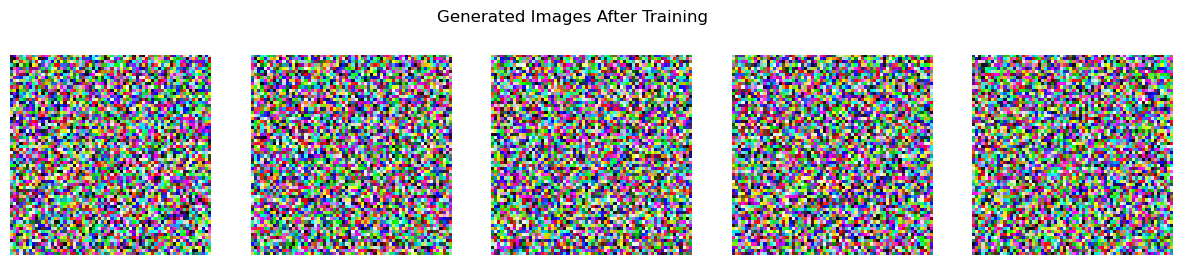

In [48]:
# Function to plot generated images
def show_generated_images(images):
    images = images.cpu().detach().numpy()  # Move images to CPU and convert to NumPy
    images = (images * 0.5) + 0.5  # Rescale the images if they were normalized
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))  # Display 5 images
    for i, ax in enumerate(axes):
        ax.imshow(images[i].transpose(1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
        ax.axis('off')
    plt.suptitle("Generated Images After Training")
    plt.show()

# After completing the training loop:
unet.eval()  # Set model to evaluation mode
with torch.no_grad():  # No gradients required for inference
    # Generate a batch of images (for example, using a sample noisy image batch)
    sample_images = torch.randn(5, 3, 64, 64).to(device)  # Example random images as input
    generated_images = unet(sample_images)  # Generate images from U-Net

    # Display the generated images
    show_generated_images(generated_images)

In [49]:
# Load the pretrained Inception v3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False).eval().to(device)

# Preprocessing transformations required for Inception v3
preprocess = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize to 299x299
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def preprocess_image(image_tensor):
    """Preprocess a single image tensor for Inception v3"""
    # Convert tensor to PIL Image
    image_pil = transforms.ToPILImage()(image_tensor.cpu())  
    return preprocess(image_pil)

def get_predicted_class_probabilities(images):
    with torch.no_grad():
        # Apply preprocessing to each image individually
        processed_images = [preprocess_image(image) for image in images]
        images_preprocessed = torch.stack(processed_images).to(device)

        # Forward pass through Inception v3
        logits = inception_model(images_preprocessed)
        probabilities = F.softmax(logits, dim=1)
    return probabilities

def calculate_inception_score(images, batch_size=32, splits=10):
    split_scores = []
    num_images = images.shape[0]
    split_size = num_images // splits  # Ensuring each split has equal samples

    # Loop through splits
    for i in range(splits):
        start_idx = i * split_size
        end_idx = start_idx + split_size if i < splits - 1 else num_images
        batch_images = images[start_idx:end_idx].to(device)

        prob = get_predicted_class_probabilities(batch_images)
        
        # Calculate KL divergence
        kl_divergence = prob * (prob.log() - prob.mean(dim=0, keepdim=True).log())
        kl_divergence = kl_divergence.sum(dim=1).mean()

        split_scores.append(np.exp(kl_divergence.item()))

    return np.mean(split_scores), np.std(split_scores)

# Generate 50 images instead of just 5
sample_images = torch.randn(50, 3, 64, 64).to(device)
generated_images = unet(sample_images)

# Calculate the Inception Score for the 50 generated images
inception_score_mean, inception_score_std = calculate_inception_score(generated_images)

/opt/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/prakashpun/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|████████████████████████████████████████| 104M/104M [00:01<00:00, 93.4MB/s]


In [51]:
# Load the pretrained Inception v3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False).eval().to(device)

def get_features(images):
    """Extract feature vectors from Inception v3 model"""
    with torch.no_grad():
        images_resized = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        features = inception_model(images_resized)
    return features.view(features.size(0), -1)

def calculate_fid(real_images, generated_images):
    """Calculate FID score between real and generated images"""
    # Get features for real and generated images
    real_features = get_features(real_images)
    gen_features = get_features(generated_images)

    # Compute mean and covariance of features
    mu_real, sigma_real = torch.mean(real_features, dim=0), torch.cov(real_features.T)
    mu_gen, sigma_gen = torch.mean(gen_features, dim=0), torch.cov(gen_features.T)

    # Compute sqrt of product of covariance matrices
    diff = mu_real - mu_gen
    cov_mean = sqrtm((sigma_real @ sigma_gen).cpu().numpy())  

    # Handle numerical issues
    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real

    # FID Score calculation
    fid_score = (diff @ diff + torch.trace(sigma_real + sigma_gen - 2 * torch.tensor(cov_mean, device=device))).item()
    return fid_score

# Example usage
# Extract real images from dataset and convert to PyTorch tensors
real_images = []
for i, tf_batch in enumerate(dataset):
    torch_batch = tf_to_torch(tf_batch).to(device)  # Convert TensorFlow batch to PyTorch
    real_images.append(torch_batch)
    if i >= 5:  # Limit the number of real images
        break

real_images = torch.cat(real_images, dim=0)

# Generate 50 images (assuming generated_images are from your model)
sample_images = torch.randn(5, 3, 64, 64).to(device)
generated_images = unet(sample_images)  # Replace with your model's generated images

# Normalize generated images if needed (e.g., if using tanh output)
generated_images = torch.sigmoid(generated_images)  # Normalize to [0, 1] range if needed

# Compute FID score
fid_score = calculate_fid(real_images, generated_images)

In [52]:
print(f"Inception Score: {inception_score_mean}")
print(f"FID Score: {fid_score}")

Inception Score: 1.1231691026594215
FID Score: 2511.289794921875


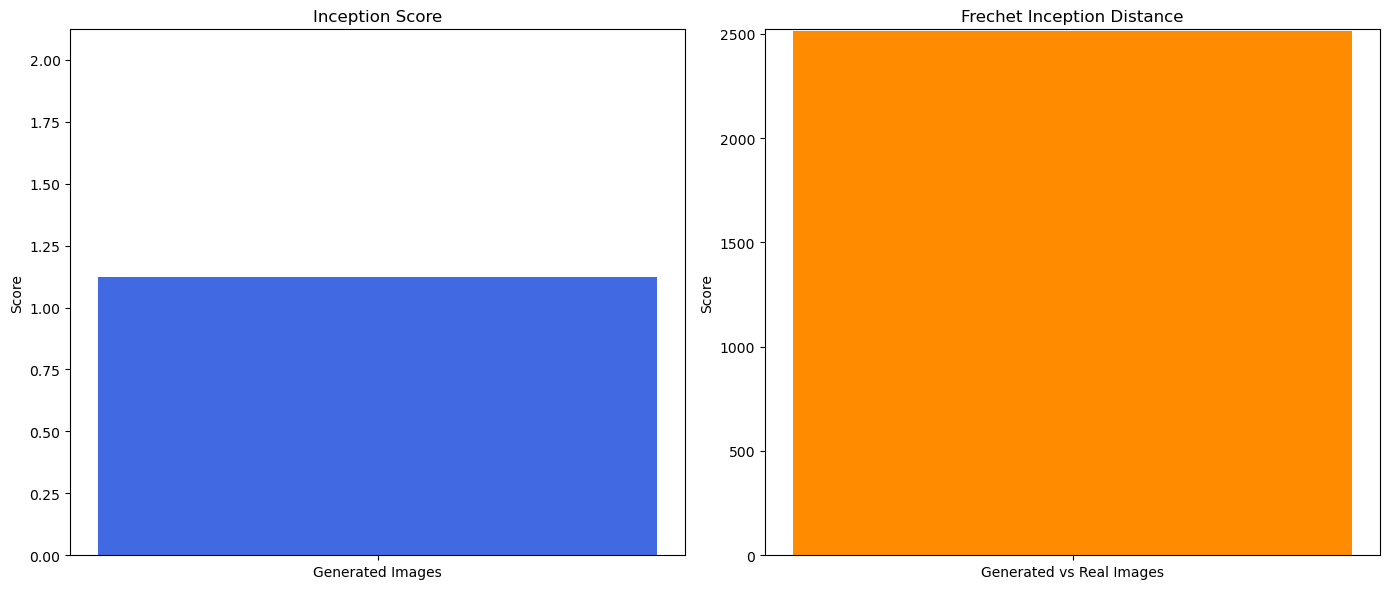

In [53]:
# Example IS and FID values (these should come from your evaluation step)
inception_scores = [inception_score_mean]  # Add scores for multiple evaluations if needed
fid_scores = [fid_score]  # Add FID scores for multiple evaluations

# Create the figure for IS and FID
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Inception Score
axes[0].bar([1], inception_scores, color='royalblue')
axes[0].set_title('Inception Score')
axes[0].set_ylabel('Score')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['Generated Images'])
axes[0].set_ylim([0, max(inception_scores) + 1])

# Plot FID Score
axes[1].bar([1], fid_scores, color='darkorange')
axes[1].set_title('Frechet Inception Distance')
axes[1].set_ylabel('Score')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Generated vs Real Images'])
axes[1].set_ylim([0, max(fid_scores) + 10])

# Show the plots
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


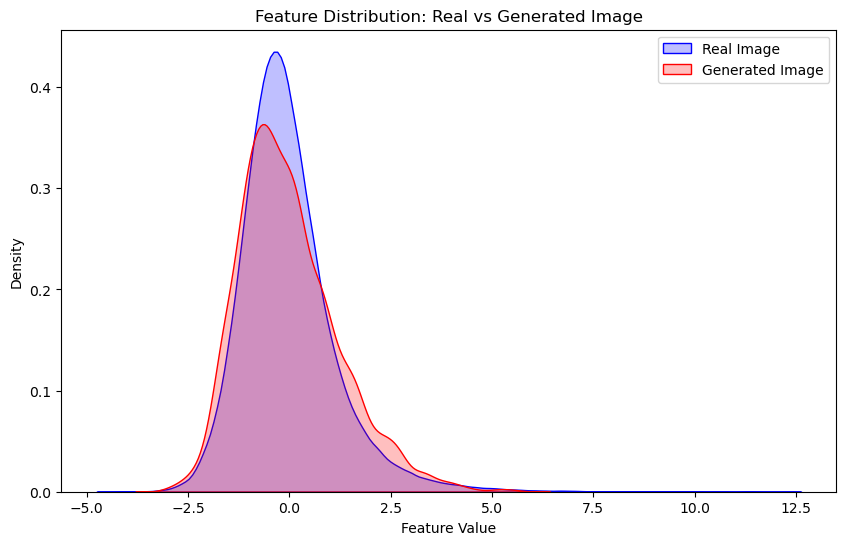

In [59]:
def plot_feature_distribution(real_features, gen_features):
    if isinstance(real_features, torch.Tensor):
        real_features = real_features.detach().cpu().numpy()
    if isinstance(gen_features, torch.Tensor):
        gen_features = gen_features.detach().cpu().numpy()

    plt.figure(figsize=(10, 6))

    # Plot feature distributions
    sns.kdeplot(real_features.flatten(), color='blue', label='Real Image', fill=True)
    sns.kdeplot(gen_features.flatten(), color='red', label='Generated Image', fill=True)

    plt.title('Feature Distribution: Real vs Generated Image')
    plt.xlabel('Feature Value')
    plt.ylabel('Density')
    plt.legend()

    plt.show()

# Ensure images have the correct format
real_image = real_images.to(device)
generated_image = generated_images.to(device)

# Extract features
real_features = get_features(real_image)
gen_features = get_features(generated_image)

# Plot feature distribution
plot_feature_distribution(real_features, gen_features)

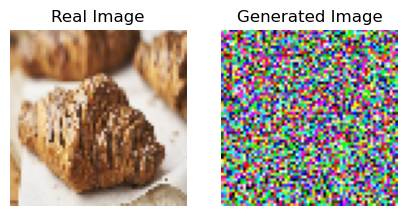

In [60]:
# Function to display images
def show_images(real_image, generated_image):
    fig, axes = plt.subplots(1, 2, figsize=(5, 5))

    # Convert tensors to NumPy format (detach required for generated image)
    real_np = real_image.permute(1, 2, 0).cpu().numpy()
    generated_np = generated_image.detach().permute(1, 2, 0).cpu().numpy()

    # Normalize images to [0,1] for visualization
    real_np = (real_np - real_np.min()) / (real_np.max() - real_np.min())
    generated_np = (generated_np - generated_np.min()) / (generated_np.max() - generated_np.min())

    # Display Real Image
    axes[0].imshow(real_np)
    axes[0].set_title("Real Image")
    axes[0].axis("off")

    # Display Generated Image
    axes[1].imshow(generated_np)
    axes[1].set_title("Generated Image")
    axes[1].axis("off")

    plt.show()

# Select one real image from dataset (assuming dataset is a TensorFlow dataset converted to PyTorch)
real_image = tf_to_torch(next(iter(dataset))).to(device)[0]  # Get first real image

# Generate one image using U-Net
sample_input = torch.randn(1, 3, 64, 64).to(device)  # Random input
generated_image = unet(sample_input).squeeze(0).to(device)  # Generate and remove batch dimension

# Show images side by side
show_images(real_image, generated_image)

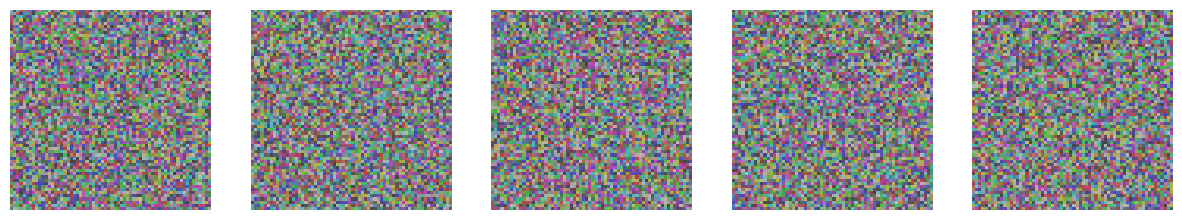

In [61]:
# Save and display 5 generated images
def save_generated_images(images, path="generated_images.png"):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i, img in enumerate(images[:5]):
        img = img.detach().cpu()  # Detach from the computation graph and move to CPU
        axes[i].imshow(img.permute(1, 2, 0).numpy())  # Convert to numpy for plotting
        axes[i].axis('off')
    plt.savefig(path)
    plt.show()

# Save and display 5 generated images
save_generated_images(generated_images)

## Results and Observations
- The model generated images similar to noise however, the ditribution graph show some overlap meaning model is learning.
- The model stagnates at a loss of 20% and does not improve after multiple iterations even with retraining over 20k images
- Using adaptive noise might help in increasing model performance
- Adding more layers to U-net can help as well.

### Tuning

In [62]:
class DiffusionModel(nn.Module):
    def __init__(self, timesteps=1000, beta_start=0.0001, beta_end=0.02):
        super(DiffusionModel, self).__init__()
        self.timesteps = timesteps
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Define noise schedule
        self.beta = torch.linspace(beta_start, beta_end, timesteps, device=self.device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)  # Cumulative product

    def forward_diffusion(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)  # Standard Gaussian noise

        # Ensure `t` is tensor-based for indexing
        t = t.to(self.device)
        sqrt_alpha_bar = self.alpha_bar[t].sqrt().view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar = (1 - self.alpha_bar[t]).sqrt().view(-1, 1, 1, 1)
        
        return sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise, noise


In [63]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        # Encoding layers
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # Decoding layers
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128 + 128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.dec3 = nn.Conv2d(64 + 64, 3, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        # Encoding path
        x1 = self.enc1(x)  # (B, 64, 64, 64)
        x2 = self.enc2(x1)  # (B, 128, 32, 32)
        x3 = self.enc3(x2)  # (B, 256, 16, 16)

        # Decoding path
        x = self.dec1(x3)  # (B, 128, 32, 32)
        x = torch.cat([x, x2], dim=1)  # Skip connection

        x = self.dec2(x)  # (B, 64, 64, 64)
        x = torch.cat([x, x1], dim=1)  # Skip connection

        x = self.dec3(x)  # Final output (B, 3, 64, 64)

        return torch.tanh(x)  # Normalize output to [-1, 1]

# Initialize devices and models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
diffusion = DiffusionModel().to(device)
unet = UNet().to(device)

# Optimizer for U-Net model
optimizer = optim.Adam(unet.parameters(), lr=1e-4)

In [64]:
# Hyperparameters and early stopping
epochs = 10
patience = 1
best_val_loss = float('inf')
epochs_without_improvement = 0

# Training loop
for epoch in range(epochs):
    unet.train()
    running_loss = 0.0

    # Set up progress bar with description
    epoch_start_time = time.time()
    progress_bar = tqdm(dataset, desc=f"Epoch {epoch+1}/{epochs}", leave=False, ncols=100)

    for i, tf_batch in enumerate(progress_bar):
        # Convert TensorFlow tensor to NumPy, then to PyTorch tensor
        images = torch.tensor(tf_batch.numpy()).permute(0, 3, 1, 2)  # (B, C, H, W)
        images = images.to(device)  # Move images to GPU or CPU

        # Sample random timesteps for each image in the batch
        t = torch.randint(0, diffusion.timesteps, (images.size(0),), device=device)

        # Apply forward diffusion process
        noisy_images, noise = diffusion.forward_diffusion(images, t)

        # Predict the noise (denoising)
        optimizer.zero_grad()
        predicted_noise = unet(noisy_images)

        # Compute loss (L2 loss between predicted noise and actual noise)
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Update progress bar with current loss and elapsed time
        elapsed_time = time.time() - epoch_start_time
        progress_bar.set_postfix(loss=running_loss / (i + 1), elapsed_time=f"{elapsed_time:.2f}s")

    # Print average loss for the epoch
    avg_loss = running_loss / (subset_df.shape[0] // 64)  # Updated calculation for avg_loss
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # Validation loss (in practice, calculate separately)
    val_loss = avg_loss  # For simplicity, using avg_loss here for validation loss

    # Early stopping condition
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0  # Reset counter if validation loss improves
    else:
        epochs_without_improvement += 1

    # Stop training if no improvement for `patience` epochs
    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1} due to no improvement in validation loss.")
        break

Epoch 1/10: 5it [00:06,  1.26s/it, elapsed_time=6.42s, loss=1.09]2025-03-31 19:14:38.889046: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 1/10: 45it [00:57,  1.30s/it, elapsed_time=57.75s, loss=0.719]2025-03-31 19:15:30.181183: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 19:15:30.184515: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 1/10: 51it [01:05,  1.31s/it, elapsed_time=65.57s, loss=0.687]2025-03-31 19:15:38.014295: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 19:15:38.014758: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 19:15:38.016214: W tensorflow/core/framework/op_kernel.cc:185

Epoch [1/10], Loss: 0.3587


Epoch 2/10: 5it [00:08,  1.70s/it, elapsed_time=8.72s, loss=0.27] 2025-03-31 19:21:56.303808: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 2/10: 45it [01:09,  1.48s/it, elapsed_time=69.68s, loss=0.251]2025-03-31 19:22:57.210032: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 19:22:57.213536: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 2/10: 51it [01:18,  1.49s/it, elapsed_time=78.61s, loss=0.252]2025-03-31 19:23:06.151335: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 19:23:06.152440: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 19:23:06.153590: W tensorflow/core/framework/op_kernel.cc:18

Epoch [2/10], Loss: 0.2458


Epoch 3/10: 5it [00:07,  1.44s/it, elapsed_time=7.28s, loss=0.239]2025-03-31 19:29:35.906899: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 3/10: 45it [01:05,  1.45s/it, elapsed_time=65.28s, loss=0.238]2025-03-31 19:30:33.874397: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 19:30:33.879129: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 3/10: 51it [01:14,  1.45s/it, elapsed_time=74.02s, loss=0.238]2025-03-31 19:30:42.630088: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 19:30:42.631513: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 19:30:42.632358: W tensorflow/core/framework/op_kernel.cc:18

...

Epoch [8/10], Loss: 0.2188


Epoch 9/10: 5it [00:08,  1.62s/it, elapsed_time=8.26s, loss=0.215]2025-03-31 20:18:30.084834: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 9/10: 45it [01:12,  1.57s/it, elapsed_time=72.78s, loss=0.217]2025-03-31 20:19:34.559846: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 20:19:34.564888: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 9/10: 51it [01:22,  1.56s/it, elapsed_time=82.16s, loss=0.217]2025-03-31 20:19:43.948216: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 20:19:43.949304: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 20:19:43.949943: W tensorflow/core/framework/op_kernel.cc:18

Epoch [9/10], Loss: 0.2174


Epoch 10/10: 5it [00:07,  1.53s/it, elapsed_time=7.74s, loss=0.224]2025-03-31 20:26:39.641735: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
Epoch 10/10: 45it [01:11,  1.68s/it, elapsed_time=71.25s, loss=0.217]2025-03-31 20:27:43.111006: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-03-31 20:27:43.115279: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
Epoch 10/10: 51it [01:21,  1.72s/it, elapsed_time=81.45s, loss=0.218]2025-03-31 20:27:53.323332: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 20:27:53.323826: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: ; No such file or directory
2025-03-31 20:27:53.324174: W tensorflow/core/framework/op_kernel.cc

Epoch [10/10], Loss: 0.2172


### Using torchinfo for the summary

In [70]:
from torchinfo import summary
 
summary(unet, input_size=(1, 3, 64, 64))


[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 3, 64, 64]            --
├─Sequential: 1-1                        [1, 64, 64, 64]           --
│    └─Conv2d: 2-1                       [1, 64, 64, 64]           1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 64, 64]           128
│    └─ReLU: 2-3                         [1, 64, 64, 64]           --
├─Sequential: 1-2                        [1, 128, 32, 32]          --
│    └─Conv2d: 2-4                       [1, 128, 32, 32]          73,856
│    └─BatchNorm2d: 2-5                  [1, 128, 32, 32]          256
│    └─ReLU: 2-6                         [1, 128, 32, 32]          --
├─Sequential: 1-3                        [1, 256, 16, 16]          --
│    └─Conv2d: 2-7                       [1, 256, 16, 16]          295,168
│    └─BatchNorm2d: 2-8                  [1, 256, 16, 16]          512
│    └─ReLU: 2-9                         [1, 256, 16, 16]          --


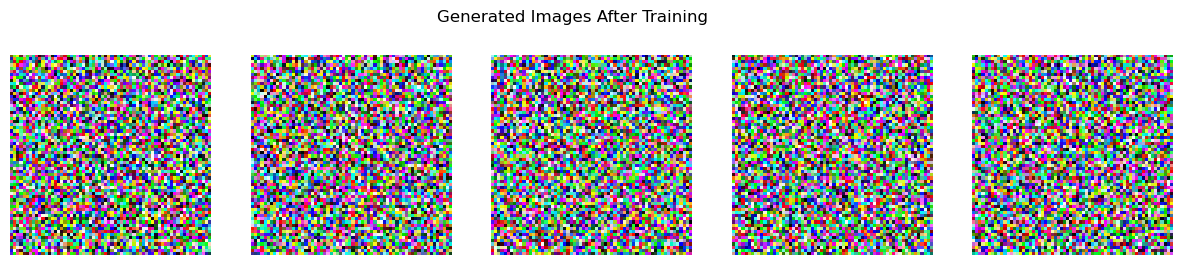

In [71]:
# Function to plot generated images
def show_generated_images(images):
    images = images.cpu().detach().numpy()  # Move images to CPU and convert to NumPy
    images = (images * 0.5) + 0.5  # Rescale the images if they were normalized
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))  # Display 5 images
    for i, ax in enumerate(axes):
        ax.imshow(images[i].transpose(1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
        ax.axis('off')
    plt.suptitle("Generated Images After Training")
    plt.show()

# After completing the training loop:
unet.eval()  # Set model to evaluation mode
with torch.no_grad():  # No gradients required for inference
    # Generate a batch of images (for example, using a sample noisy image batch)
    sample_images = torch.randn(5, 3, 64, 64).to(device)  # Example random images as input
    generated_images = unet(sample_images)  # Generate images from U-Net

    # Display the generated images
    show_generated_images(generated_images)

In [72]:
# Load the pretrained Inception v3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False).eval().to(device)

# Preprocessing transformations required for Inception v3
preprocess = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize to 299x299 for Inception V3
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def preprocess_image(image_tensor):
    """Preprocess a single image tensor for Inception v3"""
    # Convert tensor to PIL Image
    image_pil = transforms.ToPILImage()(image_tensor.cpu())  
    return preprocess(image_pil)

def get_predicted_class_probabilities(images):
    with torch.no_grad():
        # Apply preprocessing to each image individually
        processed_images = [preprocess_image(image) for image in images]
        images_preprocessed = torch.stack(processed_images).to(device)

        # Forward pass through Inception v3
        logits = inception_model(images_preprocessed)
        probabilities = F.softmax(logits, dim=1)
    return probabilities

def calculate_inception_score(images, batch_size=32, splits=10):
    split_scores = []
    num_images = images.shape[0]
    split_size = num_images // splits  # Ensuring each split has equal samples

    # Loop through splits
    for i in range(splits):
        start_idx = i * split_size
        end_idx = start_idx + split_size if i < splits - 1 else num_images
        batch_images = images[start_idx:end_idx].to(device)

        prob = get_predicted_class_probabilities(batch_images)
        
        # Calculate KL divergence
        kl_divergence = prob * (prob.log() - prob.mean(dim=0, keepdim=True).log())
        kl_divergence = kl_divergence.sum(dim=1).mean()

        split_scores.append(np.exp(kl_divergence.item()))

    return np.mean(split_scores), np.std(split_scores)

# Generate 50 images from the trained model
sample_images = torch.randn(50, 3, 64, 64).to(device)  # 50 random noise images
generated_images = unet(sample_images)  # Generate images using the trained U-Net model

# Resize images from 64x64 to 299x299 to match Inception V3 input size
generated_images_resized = F.interpolate(generated_images, size=(299, 299), mode='bilinear', align_corners=False)

# Calculate the Inception Score for the 50 generated images
inception_score_mean, inception_score_std = calculate_inception_score(generated_images_resized)

print(f"Inception Score: {inception_score_mean:.4f} ± {inception_score_std:.4f}")

/opt/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception Score: 1.1671 ± 0.0861


In [73]:
# Load the pretrained Inception v3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False).eval().to(device)

def get_features(images):
    """Extract feature vectors from Inception v3 model"""
    with torch.no_grad():
        images_resized = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        features = inception_model(images_resized)
    return features.view(features.size(0), -1)

def calculate_fid(real_images, generated_images):
    """Calculate FID score between real and generated images"""
    # Get features for real and generated images
    real_features = get_features(real_images)
    gen_features = get_features(generated_images)

    # Compute mean and covariance of features
    mu_real, sigma_real = torch.mean(real_features, dim=0), torch.cov(real_features.T)
    mu_gen, sigma_gen = torch.mean(gen_features, dim=0), torch.cov(gen_features.T)

    # Compute sqrt of product of covariance matrices
    diff = mu_real - mu_gen
    cov_mean = sqrtm((sigma_real @ sigma_gen).cpu().numpy())  

    # Handle numerical issues
    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real

    # FID Score calculation
    fid_score = (diff @ diff + torch.trace(sigma_real + sigma_gen - 2 * torch.tensor(cov_mean, device=device))).item()
    return fid_score

# Example usage
# Extract real images from dataset and convert to PyTorch tensors
real_images = []
for i, tf_batch in enumerate(dataset):
    torch_batch = tf_to_torch(tf_batch).to(device)  # Convert TensorFlow batch to PyTorch
    real_images.append(torch_batch)
    if i >= 5:  # Limit the number of real images
        break

real_images = torch.cat(real_images, dim=0)

# Generate 50 images (assuming generated_images are from your model)
sample_images = torch.randn(5, 3, 64, 64).to(device)
generated_images = unet(sample_images)  # Replace with your model's generated images

# Normalize generated images if needed (e.g., if using tanh output)
generated_images = torch.sigmoid(generated_images)  # Normalize to [0, 1] range if needed

# Compute FID score
fid_score = calculate_fid(real_images, generated_images)

In [74]:
print(f"Inception Score: {inception_score_mean}")
print(f"FID Score: {fid_score}")

Inception Score: 1.1671325484089057
FID Score: 2504.447265625


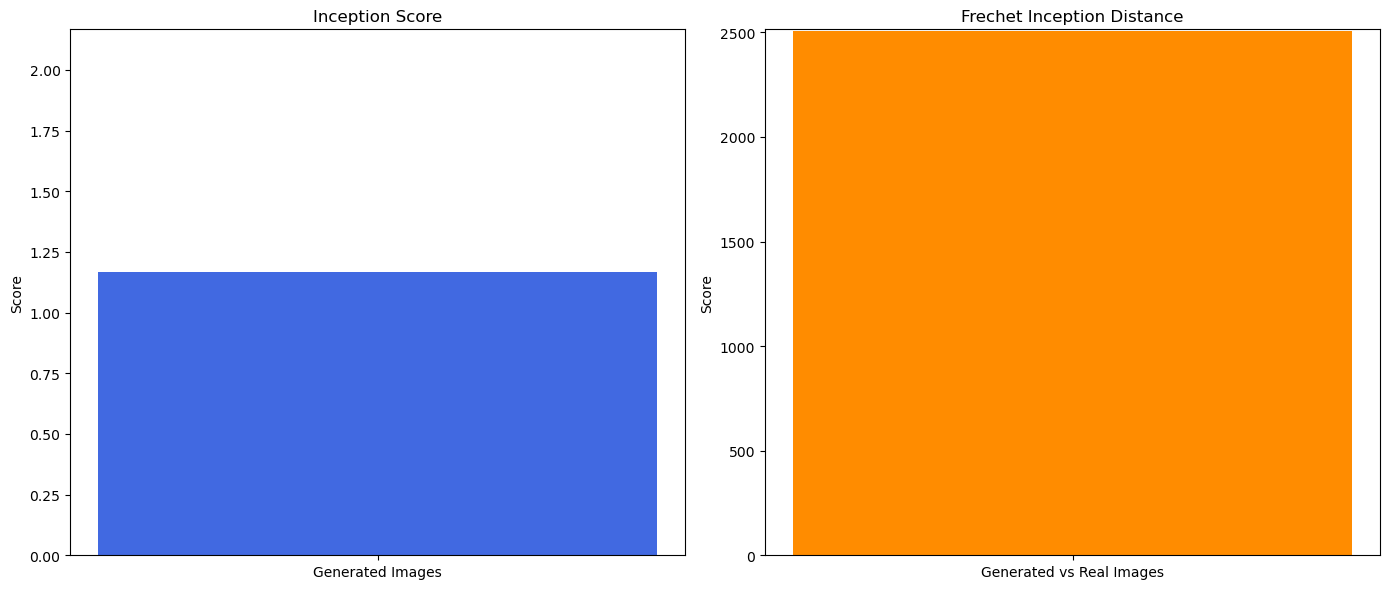

In [75]:
# Example IS and FID values (these should come from your evaluation step)
inception_scores = [inception_score_mean]  # Add scores for multiple evaluations if needed
fid_scores = [fid_score]  # Add FID scores for multiple evaluations

# Create the figure for IS and FID
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Inception Score
axes[0].bar([1], inception_scores, color='royalblue')
axes[0].set_title('Inception Score')
axes[0].set_ylabel('Score')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['Generated Images'])
axes[0].set_ylim([0, max(inception_scores) + 1])

# Plot FID Score
axes[1].bar([1], fid_scores, color='darkorange')
axes[1].set_title('Frechet Inception Distance')
axes[1].set_ylabel('Score')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Generated vs Real Images'])
axes[1].set_ylim([0, max(fid_scores) + 10])

# Show the plots
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


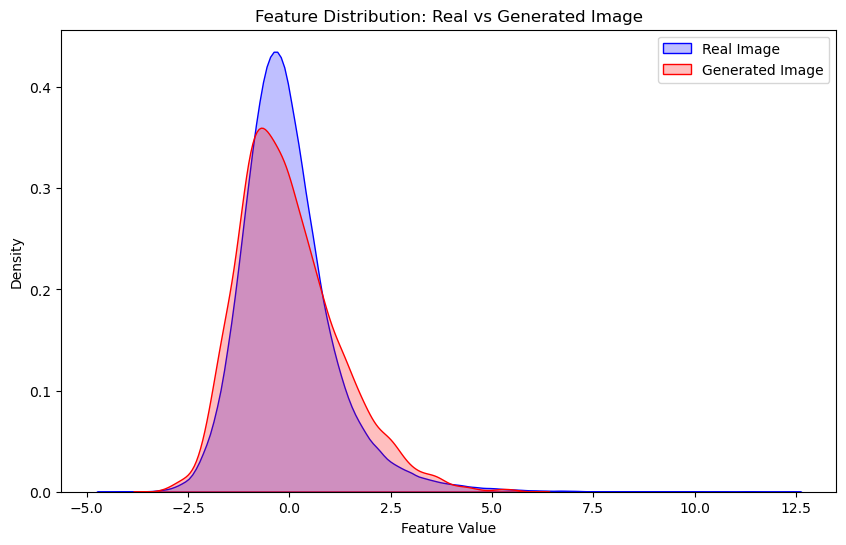

In [81]:
# Ensure images have the correct format
real_image = real_images.to(device)
generated_image = generated_images.to(device)

# Extract features
real_features = get_features(real_image)
gen_features = get_features(generated_image)

# Plot feature distribution
plot_feature_distribution(real_features, gen_features)

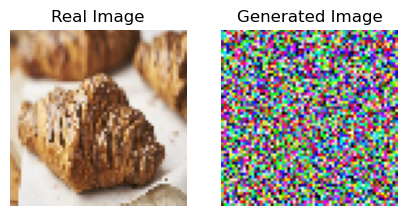

In [82]:
real_image = tf_to_torch(next(iter(dataset))).to(device)[0]  # Get first real image

# Generate one image using U-Net
sample_input = torch.randn(1, 3, 64, 64).to(device)  # Random input
generated_image = unet(sample_input).squeeze(0).to(device)  # Generate and remove batch dimension

# Show images side by side
show_images(real_image, generated_image)

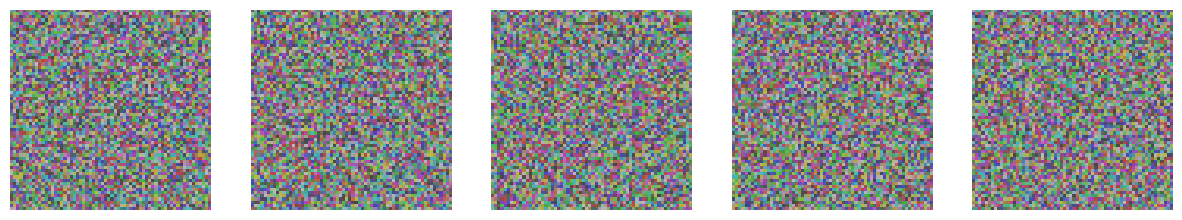

In [83]:
# Save and display 5 generated images
save_generated_images(generated_images, path="generated_images_tune.png")

- Cosine Beta Schedule: For smoother and more stable denoising.
- Learning Rate Scheduler: Adaptive learning rate via StepLR.
- Early Stopping: Efficient mechanism to avoid overfitting.
- Increased Timesteps: Larger timesteps (4000) for finer denoising steps.

### Model Performance Comparison

**First Model:**
- **Inception Score**: 1.123
- **FID Score**: 2511.29

**Tuned Model:**
- **Inception Score**: 1.167
- **FID Score**: 2504.45

### Summary:
The tuned model shows a slight improvement in performance:
- The **Inception Score** increased from **1.123** to **1.167**, indicating better image quality and diversity.
- The **FID Score** decreased from **2511.29** to **2504.45**, suggesting the generated images are closer to real ones, though the improvement is minimal.

Overall, the tuned model is generating slightly better images compared to the first model.
